In [76]:
#importing dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Loading the data

In [3]:
df = pd.read_excel('C:\\Users\\DELL\\Downloads\\flight-fare\\Flight_Fare.xlsx')

In [4]:
df.sample(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
8507,IndiGo,15/06/2019,Delhi,Cochin,DEL → BOM → COK,07:30,21:00,13h 30m,1 stop,No info,6093
8739,SpiceJet,27/05/2019,Chennai,Kolkata,MAA → CCU,17:45,20:05,2h 20m,non-stop,No check-in baggage included,3543
8175,Jet Airways,1/05/2019,Kolkata,Banglore,CCU → BOM → BLR,14:05,22:35,8h 30m,1 stop,In-flight meal not included,10844
5748,IndiGo,27/05/2019,Delhi,Cochin,DEL → BOM → COK,04:55,21:00,16h 5m,1 stop,No info,8784
8031,Jet Airways,9/05/2019,Banglore,Delhi,BLR → DEL,19:50,22:50,3h,non-stop,In-flight meal not included,3502


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,10683.0,9087.064121,4611.359167,1759.0,5277.0,8372.0,12373.0,79512.0


In [6]:
df.describe(include="O").T

,count,unique,top,freq
Airline,10683,12,Jet Airways,3849
Date_of_Journey,10683,44,18/05/2019,504
Source,10683,5,Delhi,4537
Destination,10683,6,Cochin,4537
Route,10682,128,DEL → BOM → COK,2376
Dep_Time,10683,222,18:55,233
Arrival_Time,10683,1343,19:00,423
Duration,10683,368,2h 50m,550
Total_Stops,10682,5,1 stop,5625
Additional_Info,10683,10,No info,8345


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
df.shape

(10683, 11)

In [10]:
df.dropna(inplace=True)

In [11]:
df.duplicated().sum()

220

In [12]:
df.drop_duplicates(inplace=True)

### Data Preprocessing

In [13]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### Numerical features

In [15]:
df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"])

In [16]:
df["Journey_Day"] = df["Date_of_Journey"].dt.day

In [17]:
df["Journey_Month"] = df["Date_of_Journey"].dt.month

In [18]:
df["Journey_DOW"] = df["Date_of_Journey"].dt.dayofweek

In [19]:
df.drop("Date_of_Journey",axis=1,inplace=True)

In [20]:
df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour

In [21]:
df["Dep_Minute"] = pd.to_datetime(df["Dep_Time"]).dt.minute

In [22]:
df.drop("Dep_Time",axis=1,inplace=True)

In [23]:
df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour

In [24]:
df["Arrival_Minute"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

In [25]:
df.drop("Arrival_Time",axis=1,inplace=True)

In [26]:
df['Duration']=df['Duration'].str.replace('h','*60').str.replace(' ','+').str.replace('m','*1').apply(eval)

### Categorical features

In [27]:
df.Total_Stops.value_counts()

Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

In [28]:
df["Total_Stops"] = df["Total_Stops"].replace({"non-stop" : 0,
                                                         "1 stop" : 1,
                                                         "2 stops" : 2,
                                                         "3 stops" : 3,
                                                         "4 stops" : 4})

### Additional info

In [29]:
df.Additional_Info.value_counts()

Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [30]:
#df.drop(columns='Additional_Info',axis=1,inplace=True)
df.Additional_Info=df.Additional_Info.map({'No info':8,'No Info':8,'In-flight meal not included':7,'No check-in baggage included':6,'1 Long layover':5,'Change airports':4,'Business class':3,'1 Short layover':2,'Red-eye flight':1,'2 Long layover':0})

In [31]:
from sklearn.preprocessing import  LabelEncoder
le = LabelEncoder()




### Airline

In [32]:
df["Airline"].value_counts().sort_index()

Airline
Air Asia                              319
Air India                            1694
GoAir                                 194
IndiGo                               2043
Jet Airways                          3700
Jet Airways Business                    6
Multiple carriers                    1196
Multiple carriers Premium economy      13
SpiceJet                              815
Trujet                                  1
Vistara                               478
Vistara Premium economy                 3
Name: count, dtype: int64

In [33]:
df["Airline"] = le.fit_transform(df["Airline"])

### Source

In [34]:
df["Source"].value_counts().sort_index()

Source
Banglore    2179
Chennai      381
Delhi       4345
Kolkata     2860
Mumbai       697
Name: count, dtype: int64

In [35]:
df['Source'] = le.fit_transform(df['Source'])

### Destination

In [36]:
df["Destination"].value_counts()

Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [38]:
df['Destination'] = le.fit_transform(df['Destination'])

In [39]:
df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_DOW,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,3,0,5,BLR → DEL,170,0,8,3897,24,3,6,22,20,1,10
1,1,3,0,CCU → IXR → BBI → BLR,445,2,8,7662,1,5,2,5,50,13,15


### EDA

<Axes: xlabel='Journey_DOW', ylabel='count'>

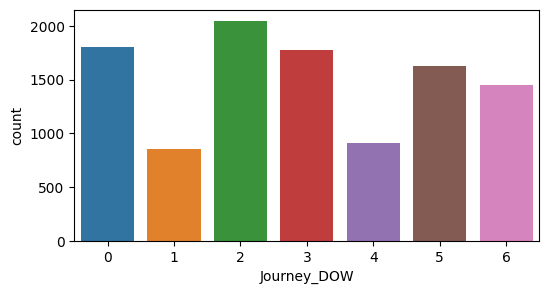

In [40]:
plt.figure(figsize=(6,3))
sns.countplot(x="Journey_DOW", data=df)

<Axes: xlabel='Journey_Month', ylabel='count'>

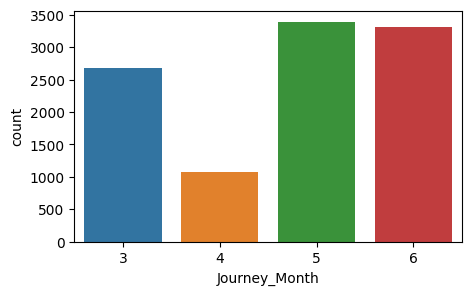

In [41]:
plt.figure(figsize=(5,3))
sns.countplot(x="Journey_Month", data=df)

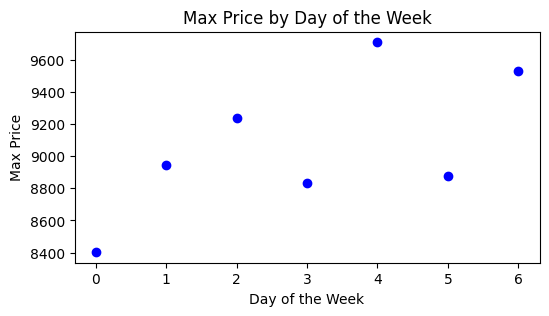

In [42]:
max_prices = df.groupby("Journey_DOW")["Price"].mean()
plt.figure(figsize=(6, 3))
plt.scatter(max_prices.index, max_prices.values, color='b', marker='o')
plt.xlabel('Day of the Week')
plt.ylabel('Max Price')
plt.title('Max Price by Day of the Week')
plt.show()

<Axes: xlabel='Total_Stops', ylabel='count'>

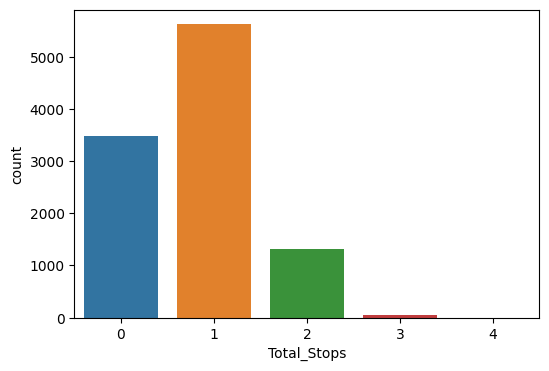

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(x="Total_Stops", data=df)

<Axes: xlabel='Destination', ylabel='count'>

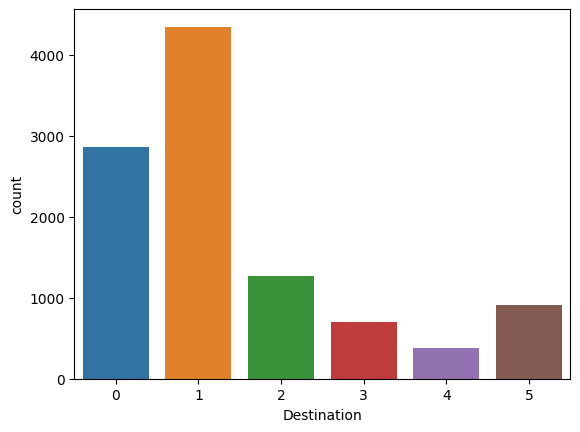

In [44]:
sns.countplot(x="Destination",data=df)

<Axes: xlabel='Duration', ylabel='Count'>

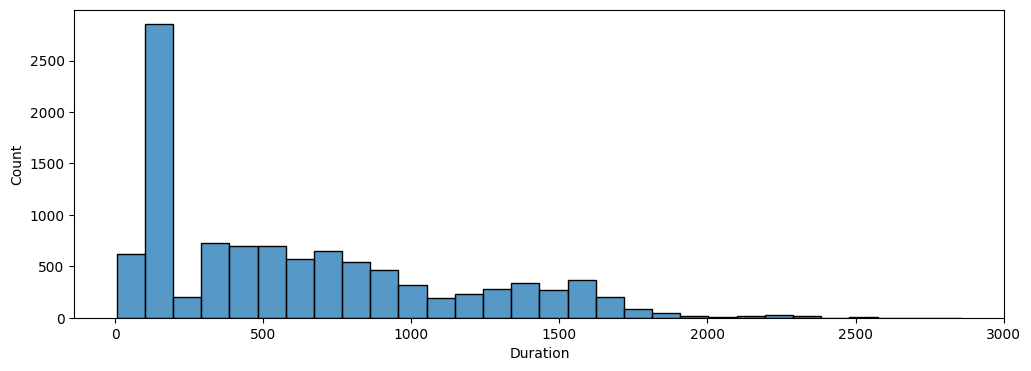

In [45]:
plt.figure(figsize=(12,4))
sns.histplot(data=df, x="Duration",bins=30)

<Axes: xlabel='Arrival_Hour', ylabel='Count'>

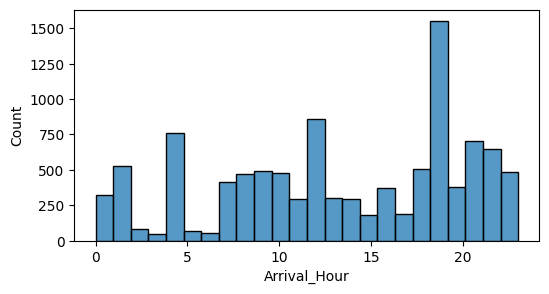

In [46]:
plt.figure(figsize=(6,3))
sns.histplot(data=df, x="Arrival_Hour",bins=24)

<Axes: xlabel='Dep_Hour', ylabel='Count'>

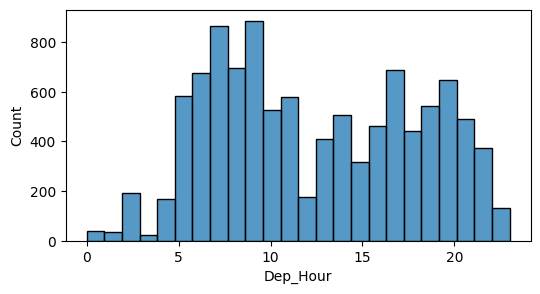

In [47]:
plt.figure(figsize=(6,3))
sns.histplot(data=df, x="Dep_Hour",bins=24)

<Axes: xlabel='Price', ylabel='Count'>

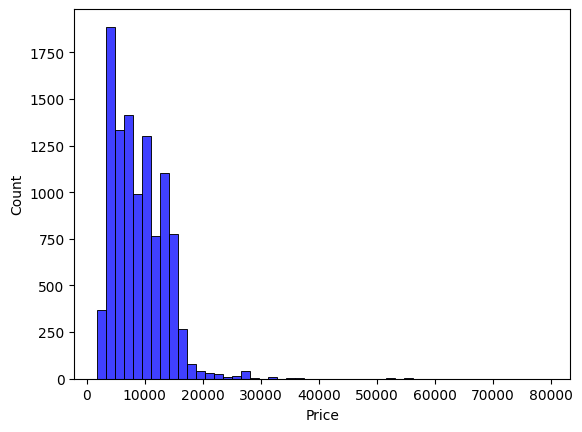

In [48]:
sns.histplot(data=df, x="Price",bins=50,color='blue')

<Axes: xlabel='Duration', ylabel='Price'>

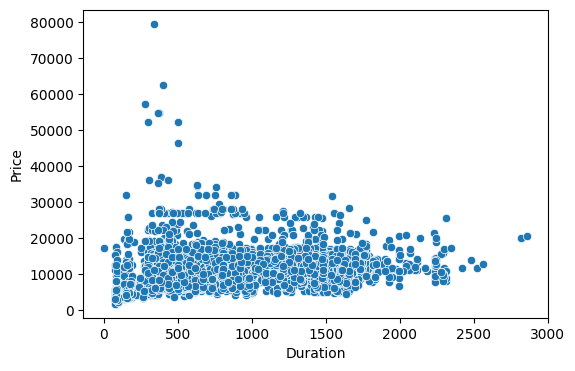

In [49]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Duration", y="Price")

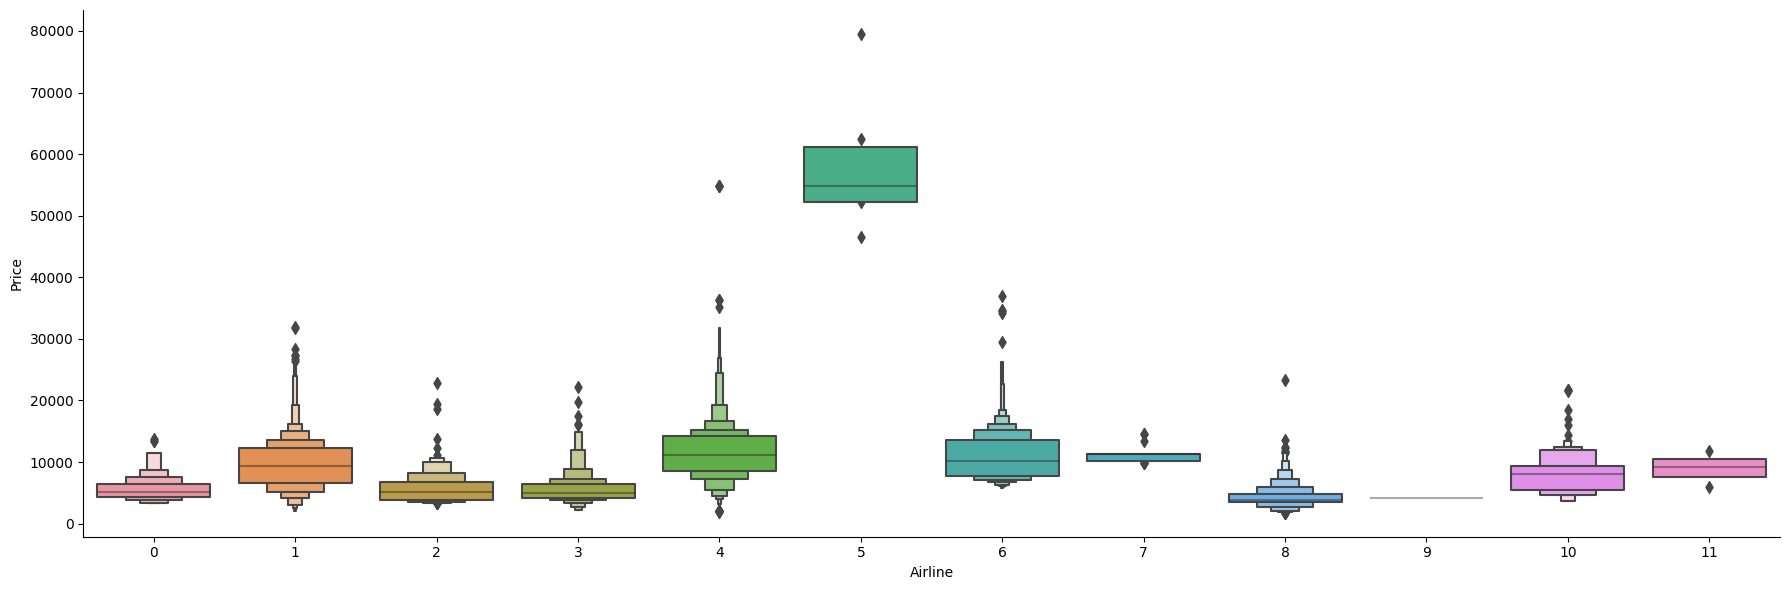

In [50]:
sns.catplot(y = "Price", x = "Airline", data = df.sort_values("Price", ascending = False), kind="boxen", height = 6, aspect = 3)
plt.show()

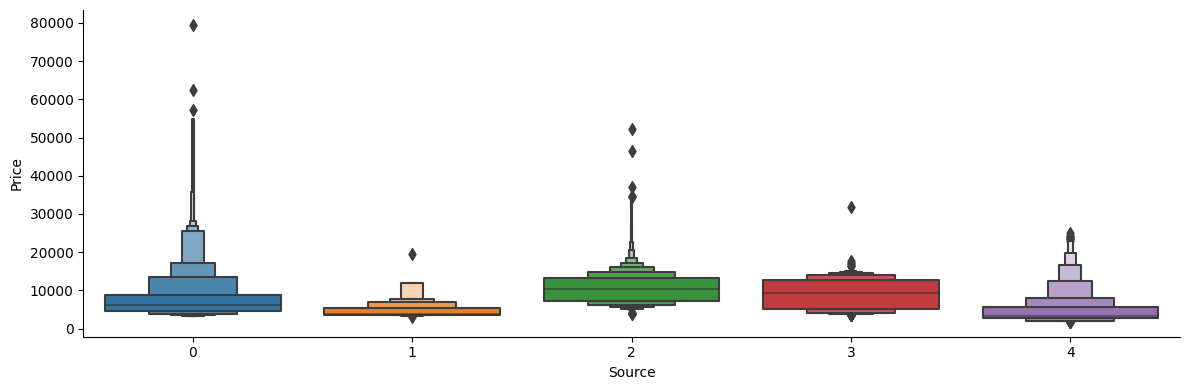

In [51]:
sns.catplot(y = "Price", x = "Source", data = df.sort_values("Price", ascending = False), kind="boxen", height = 4, aspect = 3)
plt.show()

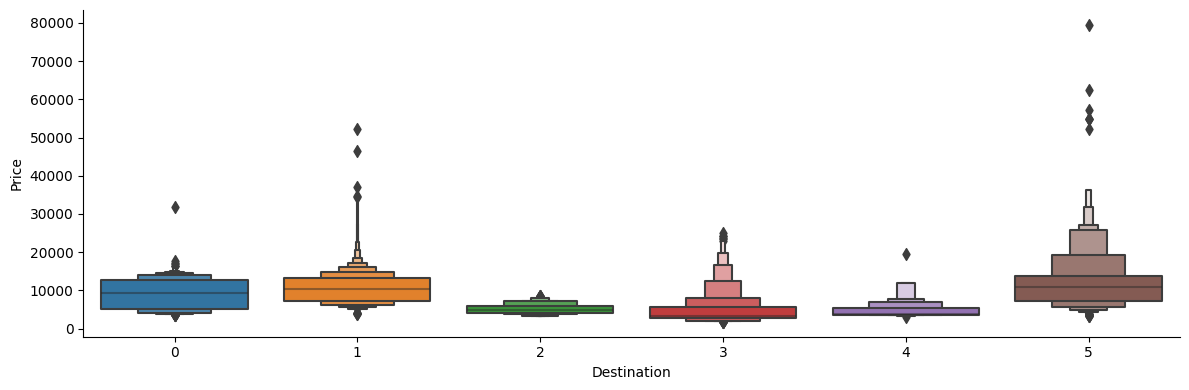

In [52]:
sns.catplot(y = "Price", x = "Destination", data = df.sort_values("Price", ascending = False), kind="boxen", height = 4, aspect = 3)
plt.show()

In [53]:
df.drop(columns='Route',axis=1,inplace=True)

In [54]:
df.sample()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_DOW,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
6928,4,2,1,1655,1,7,10262,12,6,2,9,0,12,35


In [55]:
df.corr()["Price"]

Airline           -0.036491
Source             0.013796
Destination       -0.065875
Duration           0.501758
Total_Stops        0.602013
Additional_Info    0.017603
Price              1.000000
Journey_Day       -0.159044
Journey_Month     -0.113396
Journey_DOW        0.055846
Dep_Hour           0.005155
Dep_Minute        -0.024155
Arrival_Hour       0.031023
Arrival_Minute    -0.086163
Name: Price, dtype: float64

<Axes: >

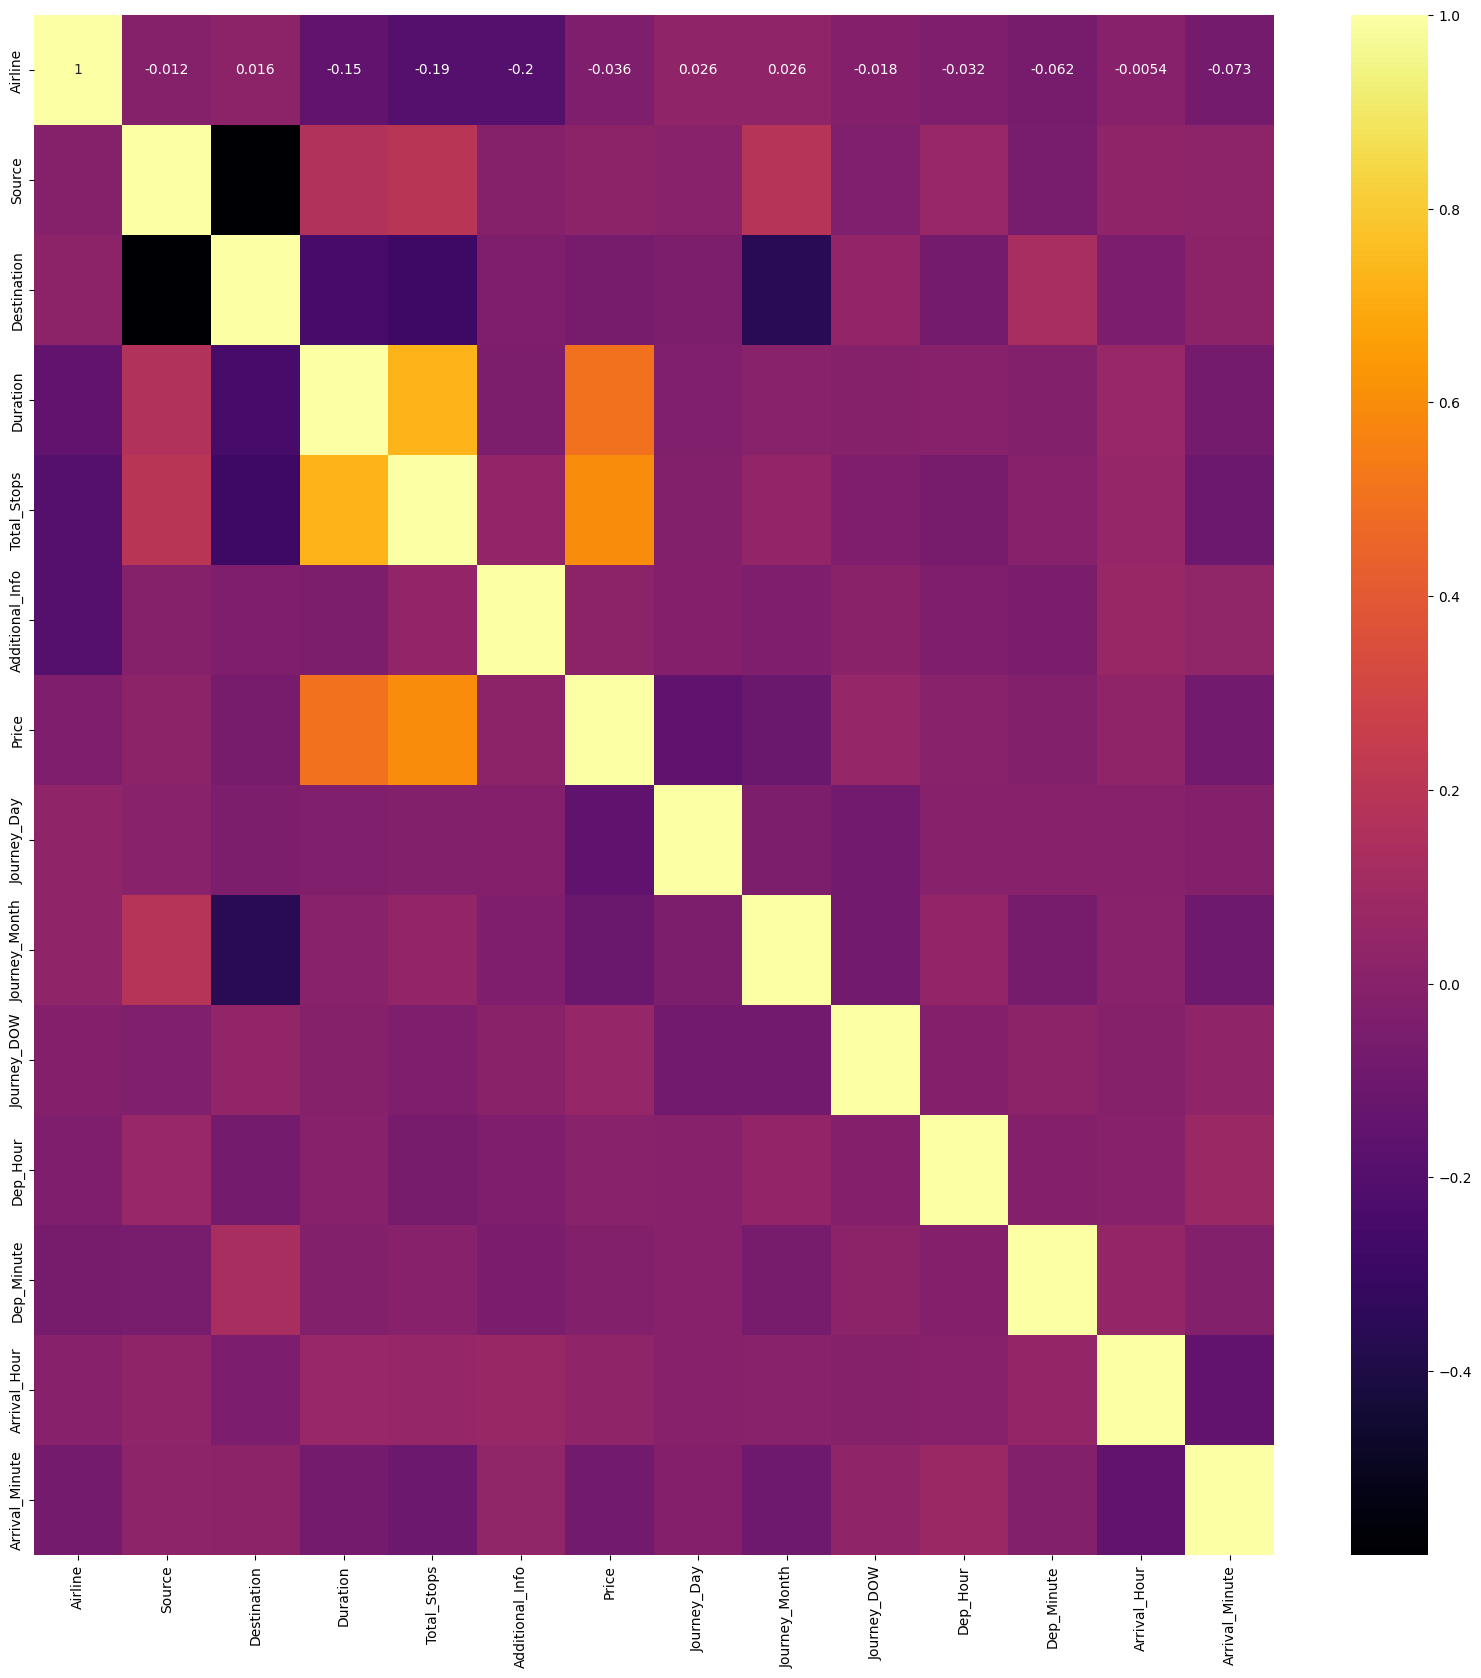

In [56]:
columns = [col for col in df.columns if df[col].nunique()>3]
plt.figure(figsize=(20,20))
sns.heatmap(df[columns].corr(),annot=True,cmap="inferno")

In [57]:
df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_DOW,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,3,0,5,170,0,8,3897,24,3,6,22,20,1,10
1,1,3,0,445,2,8,7662,1,5,2,5,50,13,15
2,4,2,1,1140,2,8,13882,9,6,6,9,25,4,25
3,3,3,0,325,1,8,6218,12,5,6,18,5,23,30
4,3,0,5,285,1,8,13302,1,3,4,16,50,21,35


In [58]:
X = df.drop("Price",axis=1)

In [59]:
y = df["Price"]

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [62]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [63]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "ElasticNet Regression": ElasticNet(),
    "SVR": SVR(kernel='rbf'),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(),
    "Gradient Boosting Regression": GradientBoostingRegressor(),
    "XGBoost Regression": XGBRegressor()
}

Model_name = []
Model_acc = []

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test) 
    print(name)
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    print(f"R^2 Score: {r2_score(y_test,y_pred):.4f}")
    print("-"*50)
    Model_name.append(name)
    Model_acc.append(f"{r2_score(y_test,y_pred):.4f}")


Linear Regression
MAE: 2434.4298
MSE: 11892132.3165
RMSE: 3448.4971
R^2 Score: 0.4430
--------------------------------------------------
Ridge Regression
MAE: 2434.4209
MSE: 11892193.5358
RMSE: 3448.5060
R^2 Score: 0.4430
--------------------------------------------------
Lasso Regression
MAE: 2434.3974
MSE: 11892500.9394
RMSE: 3448.5506
R^2 Score: 0.4430
--------------------------------------------------
ElasticNet Regression
MAE: 2636.9504
MSE: 13555382.1415
RMSE: 3681.7635
R^2 Score: 0.3651
--------------------------------------------------
SVR
MAE: 3090.7230
MSE: 18166432.5172
RMSE: 4262.2098
R^2 Score: 0.1492
--------------------------------------------------
Decision Tree Regression
MAE: 821.9391
MSE: 4432083.1127
RMSE: 2105.2513
R^2 Score: 0.7924
--------------------------------------------------
Random Forest Regression
MAE: 694.8433
MSE: 2400732.8638
RMSE: 1549.4299
R^2 Score: 0.8876
--------------------------------------------------
Gradient Boosting Regression
MAE: 1266.7742

In [64]:
table = pd.DataFrame({"Model Name" : Model_name,"R2 Score" : Model_acc})

In [65]:
table.sort_values(by="R2 Score",ascending=False,ignore_index=True)

,Model Name,R2 Score
0,XGBoost Regression,0.8974
1,Random Forest Regression,0.8876
2,Gradient Boosting Regression,0.8176
3,Decision Tree Regression,0.7924
4,Linear Regression,0.4430
5,Ridge Regression,0.4430
6,Lasso Regression,0.4430
7,ElasticNet Regression,0.3651
8,SVR,0.1492


### Hyperparameter Tuning

In [66]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

In [67]:
xgboost = XGBRegressor()

In [68]:
param_grid = {
    'n_estimators': [550],
    'learning_rate': [0.02],
    'max_depth': [8],
    'min_child_weight': [2],
    'colsample_bytree': [0.9],
    'gamma': [0.01],
    'reg_lambda': [0.9],
    'reg_alpha': [1],
    'subsample': [0.8],
}

In [70]:
xgbreg = XGBRegressor()

In [71]:
grid_CV = GridSearchCV(estimator=xgbreg, param_grid=param_grid,cv=5,n_jobs=-1,verbose=1)

In [72]:
grid_CV.fit(X_train,y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.9], 'gamma': [0.01],
                         'learning_rate': [0.02], 'max_depth': [8],
                         'min_child_weight': [2], 'n_estimators': [550],
                         'reg_alpha': [1], 'reg_lambda': [0.9],
                         'subsample': [0.8]},
             verbose=1)

In [73]:
grid_CV.best_params_

{'colsample_bytree': 0.9,
 'gamma': 0.01,
 'learning_rate': 0.02,
 'max_depth': 8,
 'min_child_weight': 2,
 'n_estimators': 550,
 'reg_alpha': 1,
 'reg_lambda': 0.9,
 'subsample': 0.8}

In [74]:
y_pred = grid_CV.predict(X_test)

In [75]:
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R^2 Score: {r2_score(y_test,y_pred):.4f}")

MAE: 721.9165
MSE: 1992209.6580
RMSE: 1411.4566
R^2 Score: 0.9067
